# Прогнозирование почасового трафика на перекрёстке

Итоговый проект по курсу «Анализ временных рядов».

Ноутбук содержит все этапы исследования:

1. Загрузка и очистка данных
2. Разведочный анализ (EDA) и постановка задачи
3. Статистические модели
4. ML-модели с feature engineering
5. Нейросетевые модели
6. Выявление аномалий
7. Финальные выводы

## 1. Загрузка и очистка данных

Исходный файл `data/traffic.csv` содержит почасовые замеры количества
транспортных средств на нескольких перекрёстках. По заданию используем только
перекрёсток `Junction == 1` — для него ряд наиболее длинный и полный.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

DATA_PATH = os.path.join('..', 'data', 'traffic.csv')
raw = pd.read_csv(DATA_PATH)
raw.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [2]:
# Общая информация о таблице: типы, количество строк, объём памяти
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [3]:
# Проверка пропусков и дубликатов
print('Пропуски по столбцам:')
print(raw.isna().sum())
print('\nЯвные дубликаты строк:', raw.duplicated().sum())
print('Перекрёстки в данных:', sorted(raw['Junction'].unique().tolist()))
print('Записей по перекрёсткам:')
print(raw['Junction'].value_counts().sort_index())

Пропуски по столбцам:
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

Явные дубликаты строк: 0
Перекрёстки в данных: [1, 2, 3, 4]
Записей по перекрёсткам:
Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64


### Отбор перекрёстка и приведение индекса

Берём `Junction == 1`, приводим `DateTime` к типу `datetime64`, делаем его
индексом и сортируем. Столбец `ID` (порядковый номер) для анализа не нужен,
поэтому удаляем его.

In [4]:
df = raw.loc[raw['Junction'] == 1].copy()
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime').set_index('DateTime')
df = df.drop(columns=['Junction', 'ID'])
df = df.rename(columns={'Vehicles': 'y'})
df.head()

,y
DateTime,
2015-11-01 00:00:00,15
2015-11-01 01:00:00,13
2015-11-01 02:00:00,10
2015-11-01 03:00:00,7
2015-11-01 04:00:00,9


In [7]:
# Границы периода наблюдений и шаг ряда
print('Начало ряда :', df.index.min())
print('Конец ряда  :', df.index.max())
print('Наблюдений  :', len(df))

expected_hours = pd.date_range(df.index.min(), df.index.max(), freq='h')
missing_hours = expected_hours.difference(df.index)
print('Ожидалось часов (без пропусков):', len(expected_hours))
print('Пропущенных часов             :', len(missing_hours))

Начало ряда : 2015-11-01 00:00:00
Конец ряда  : 2017-06-30 23:00:00
Наблюдений  : 14592
Ожидалось часов (без пропусков): 14592
Пропущенных часов             : 0


In [8]:
# Приведение к строго почасовому индексу.
# Если пропусков нет, asfreq просто зафиксирует частоту 'H' в индексе.
# Если появятся NaN — заполним их линейной интерполяцией (разумно для гладкого
# суточного профиля трафика).
df = df.asfreq('h')
print('После asfreq пропусков:', df['y'].isna().sum())
if df['y'].isna().any():
    df['y'] = df['y'].interpolate(method='time')
    print('Пропуски заполнены линейной интерполяцией.')
df.head()

После asfreq пропусков: 0


,y
DateTime,
2015-11-01 00:00:00,15
2015-11-01 01:00:00,13
2015-11-01 02:00:00,10
2015-11-01 03:00:00,7
2015-11-01 04:00:00,9


In [9]:
# Базовая описательная статистика целевой переменной
df['y'].describe().round(2)

count    14592.00
mean        45.05
std         23.01
min          5.00
25%         27.00
50%         40.00
75%         59.00
max        156.00
Name: y, dtype: float64

In [10]:
# Среднее по часу суток и дню недели — быстрая прикидка сезонных профилей
by_hour = df.groupby(df.index.hour)['y'].mean().round(1)
by_dow  = df.groupby(df.index.dayofweek)['y'].mean().round(1)
by_dow.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print('Средний трафик по часам суток:')
print(by_hour)
print('\nСредний трафик по дням недели:')
print(by_dow)

Средний трафик по часам суток:
DateTime
0     45.7
1     39.2
2     33.9
3     29.4
4     25.7
5     24.1
6     26.1
7     29.5
8     32.7
9     39.0
10    49.5
11    56.2
12    57.3
13    51.1
14    54.7
15    54.2
16    51.9
17    51.9
18    55.4
19    58.8
20    57.4
21    54.5
22    53.0
23    50.1
Name: y, dtype: float64

Средний трафик по дням недели:
Mon    49.4
Tue    51.2
Wed    50.9
Thu    50.3
Fri    47.0
Sat    34.1
Sun    32.3
Name: y, dtype: float64


## 2. Разведочный анализ и постановка задачи

Теперь визуализируем ряд на разных масштабах, оценим автокорреляции и
сезонные компоненты, проверим стационарность и зафиксируем постановку задачи.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 4)

### 2.1 Визуализация ряда

Смотрим ряд целиком, одну неделю и одни сутки. Цель — увидеть наличие
суточного цикла, недельного цикла и долгосрочного тренда.

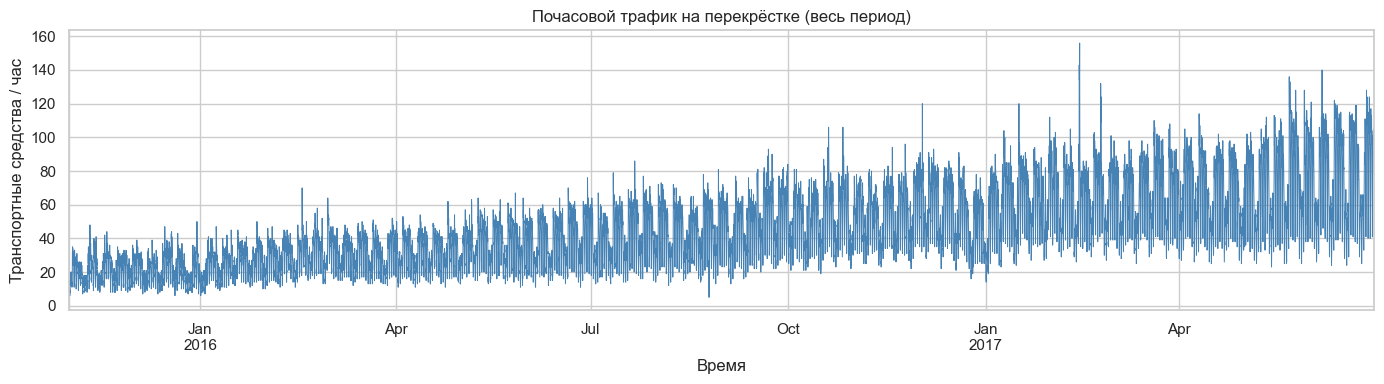

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
df['y'].plot(ax=ax, color='steelblue', linewidth=0.7)
ax.set_title('Почасовой трафик на перекрёстке (весь период)')
ax.set_ylabel('Транспортные средства / час')
ax.set_xlabel('Время')
plt.tight_layout()
plt.show()

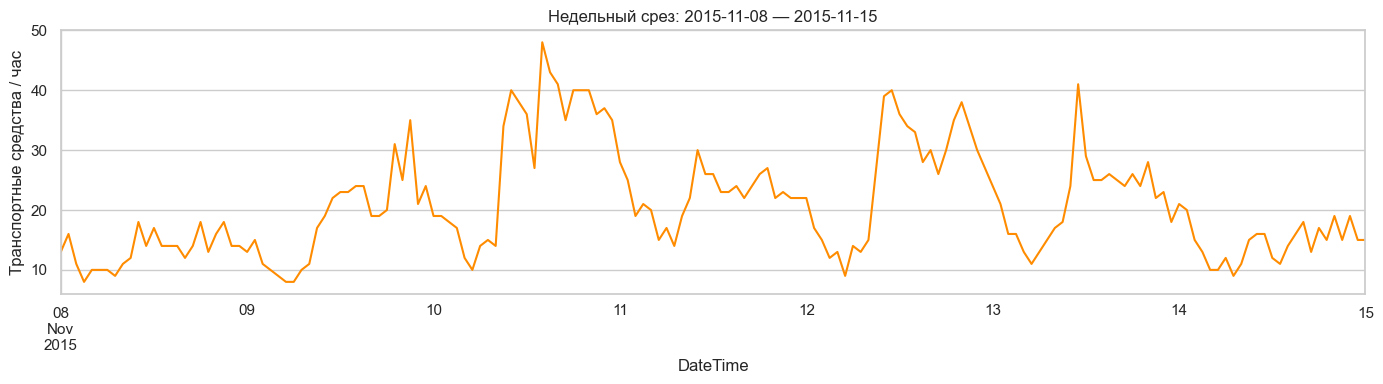

In [13]:
# Одна неделя — чтобы увидеть недельный и суточный ритм
week_start = df.index.min() + pd.Timedelta(days=7)
week = df.loc[week_start : week_start + pd.Timedelta(days=7)]

fig, ax = plt.subplots(figsize=(14, 4))
week['y'].plot(ax=ax, color='darkorange')
ax.set_title(f'Недельный срез: {week.index.min().date()} — {week.index.max().date()}')
ax.set_ylabel('Транспортные средства / час')
plt.tight_layout()
plt.show()

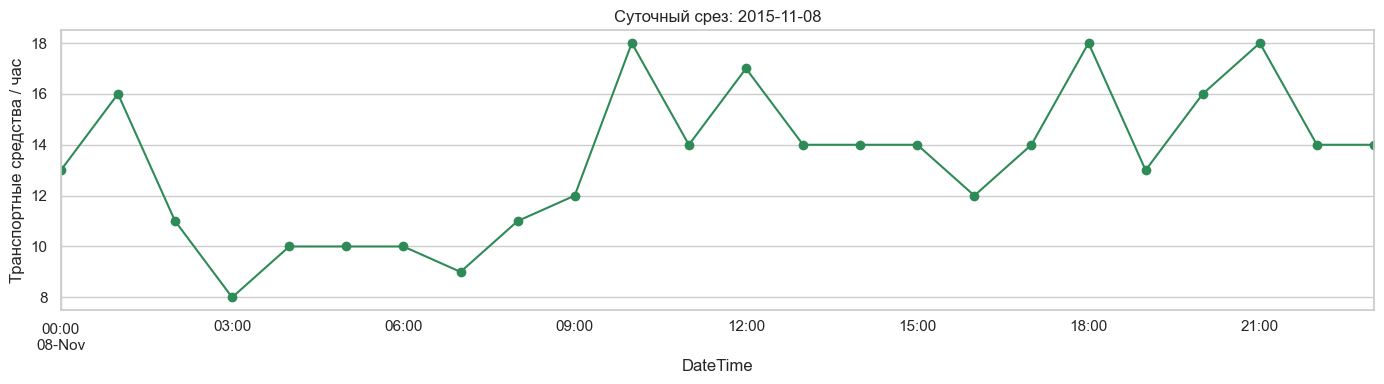

In [14]:
# Одни сутки — суточный профиль
day_start = week.index.min()
day = df.loc[day_start : day_start + pd.Timedelta(hours=23)]

fig, ax = plt.subplots(figsize=(14, 4))
day['y'].plot(ax=ax, marker='o', color='seagreen')
ax.set_title(f'Суточный срез: {day.index.min().date()}')
ax.set_ylabel('Транспортные средства / час')
plt.tight_layout()
plt.show()

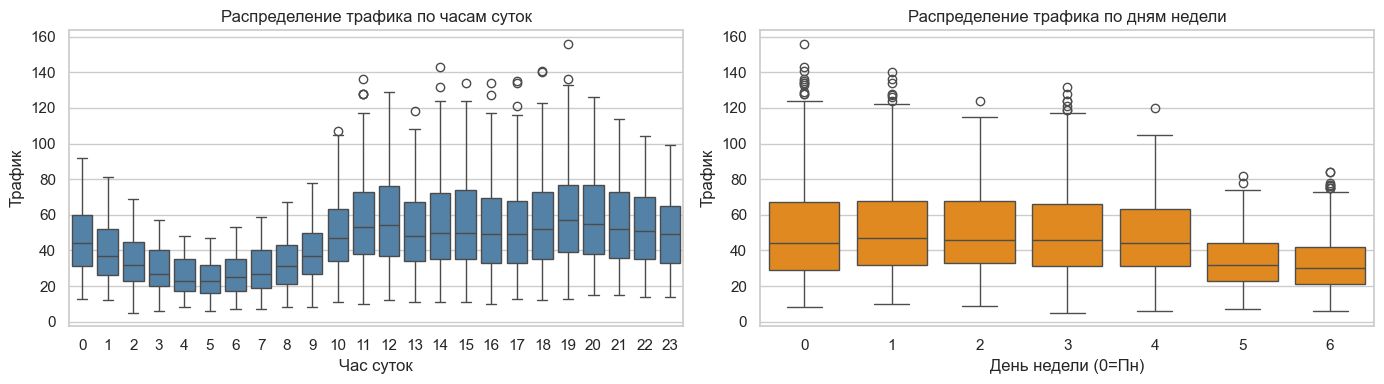

In [15]:
# Сравнение профилей по дням недели (boxplot) и по часам суток
tmp = df.copy()
tmp['hour'] = tmp.index.hour
tmp['dow']  = tmp.index.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=tmp, x='hour', y='y', ax=axes[0], color='steelblue')
axes[0].set_title('Распределение трафика по часам суток')
axes[0].set_xlabel('Час суток')
axes[0].set_ylabel('Трафик')

sns.boxplot(data=tmp, x='dow', y='y', ax=axes[1], color='darkorange')
axes[1].set_title('Распределение трафика по дням недели')
axes[1].set_xlabel('День недели (0=Пн)')
axes[1].set_ylabel('Трафик')
plt.tight_layout()
plt.show()

### 2.2 Автокорреляции

Строим ACF и PACF до лага 200. Ожидаемые пики — на лагах 24 (сутки) и 168
(неделя).

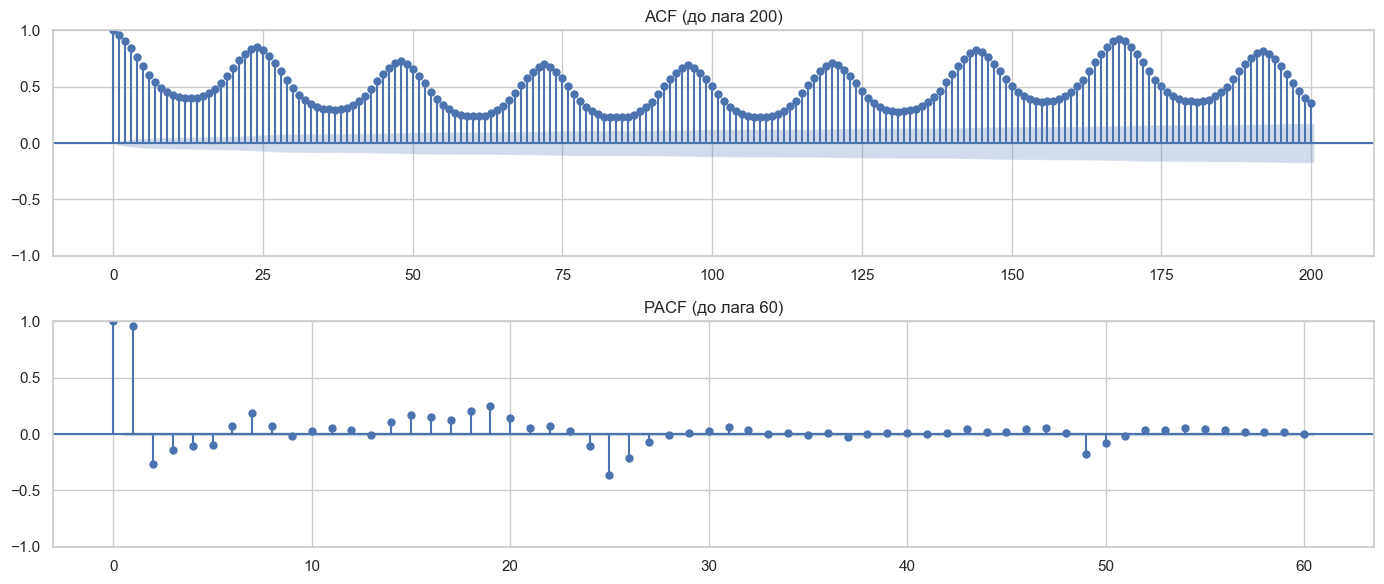

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
plot_acf(df['y'],  lags=200, ax=axes[0])
axes[0].set_title('ACF (до лага 200)')
plot_pacf(df['y'], lags=60, ax=axes[1], method='ywm')
axes[1].set_title('PACF (до лага 60)')
plt.tight_layout()
plt.show()

### 2.3 Сезонная декомпозиция

Используем аддитивную модель с периодом 24 (суточная сезонность — самая
выраженная). Для недельной сезонности можно повторить с `period=168`, но на
графике она и так будет видна по остаточной компоненте.

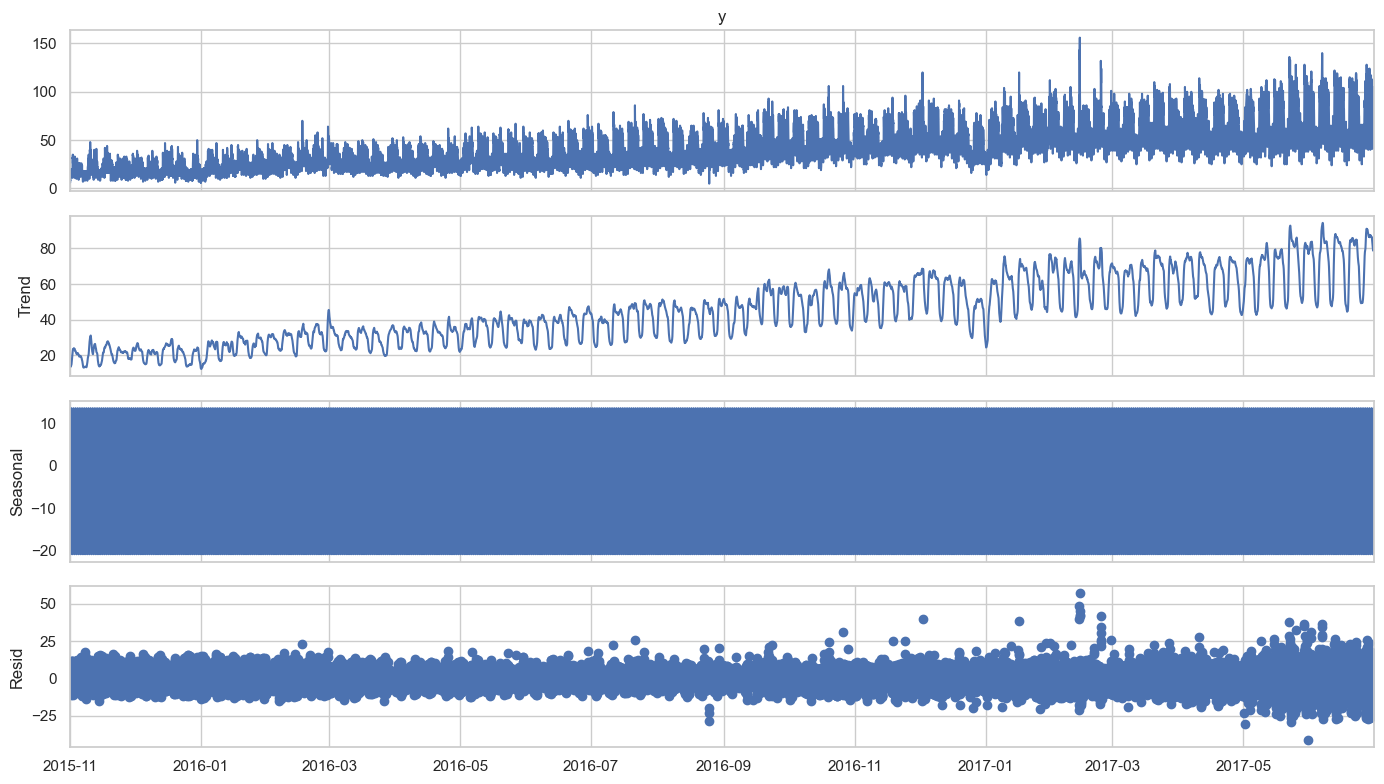

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df['y'], model='additive', period=24)
fig = decomp.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

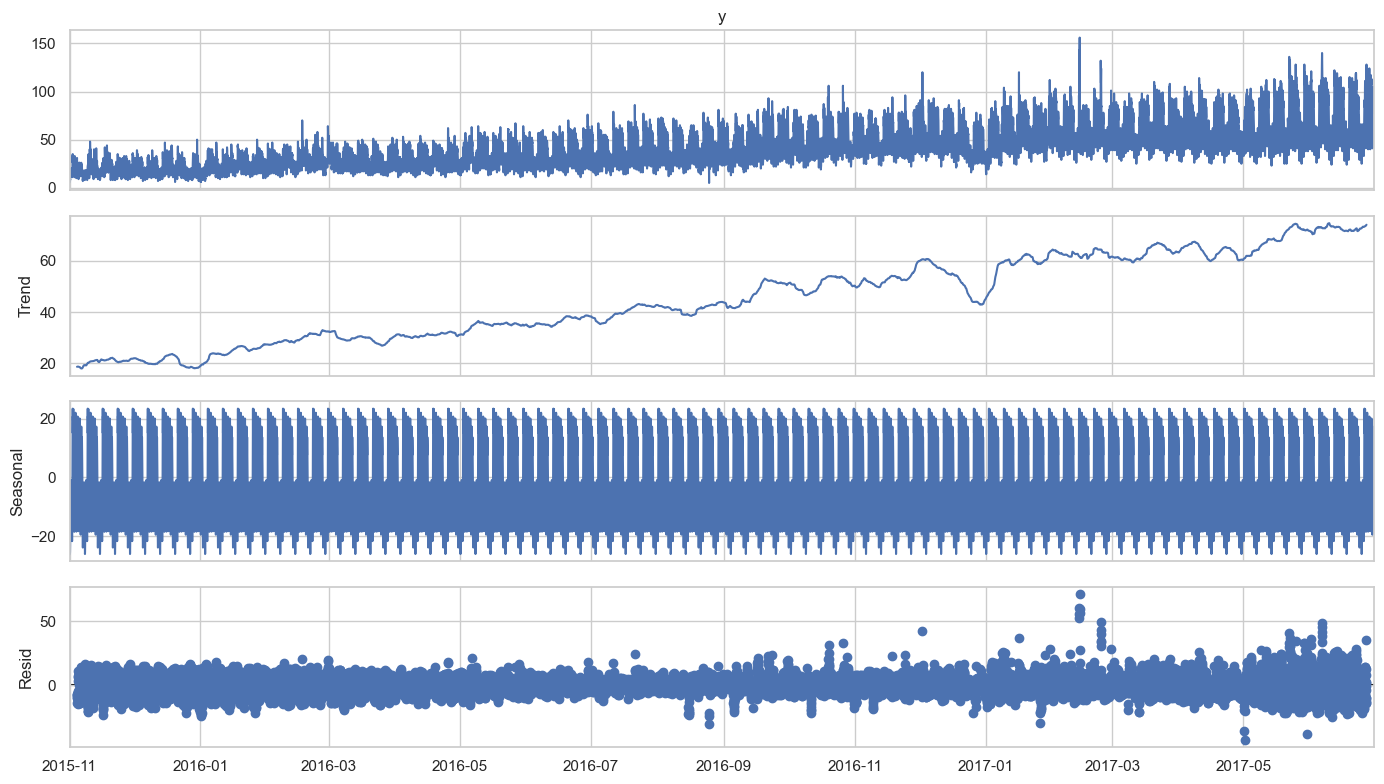

In [18]:
# То же с недельным периодом — чтобы увидеть недельный цикл отдельно
decomp_w = seasonal_decompose(df['y'], model='additive', period=168)
fig = decomp_w.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

### 2.4 Проверка стационарности (ADF)

Тест Дики-Фуллера проверяет гипотезу о наличии единичного корня.
Если p-value < 0.05 — отвергаем гипотезу нестационарности.
Обычно почасовой трафик после снятия суточной сезонности становится
стационарным, поэтому тест также проведём на сезонных разностях.

In [19]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, label):
    stat, pvalue, *_ = adfuller(series.dropna(), autolag='AIC')
    print(f'{label:35s} | ADF={stat:8.3f} | p-value={pvalue:.4f}')

adf_report(df['y'],                  'Исходный ряд')
adf_report(df['y'].diff(),           'Первая разность')
adf_report(df['y'].diff(24),         'Сезонная разность (24)')
adf_report(df['y'].diff(24).diff(),  'Сез. (24) + первая разность')

Исходный ряд                        | ADF=  -7.148 | p-value=0.0000
Первая разность                     | ADF= -21.998 | p-value=0.0000
Сезонная разность (24)              | ADF= -23.433 | p-value=0.0000
Сез. (24) + первая разность         | ADF= -23.996 | p-value=0.0000


### 2.5 Постановка задачи

**Цель.** Построить прогноз почасового трафика на перекрёстке
`Junction == 1` на ближайшие сутки.

**Горизонт прогноза.** `h = 24` часа. Такой горизонт практически востребован
(планирование работы светофоров, оценка загрузки на завтра) и одновременно
достаточно длинный, чтобы различать модели.

**Протокол валидации.** Бэктестинг (rolling cross-validation) с несколькими
окнами прогноза: минимум 5 подряд идущих 24-часовых горизонтов в конце ряда.
Финальное сравнение моделей усредняется по этим окнам.

**Метрики качества.** Используем три метрики, дополняющие друг друга:

- **MAE** — средняя абсолютная ошибка, интерпретируется в штуках машин.
- **RMSE** — корень из среднеквадратичной ошибки, штрафует крупные промахи.
- **sMAPE** — симметричная относительная ошибка в процентах, позволяет сравнивать масштабы.

**Основные выводы EDA:**

- Ряд имеет выраженную суточную (период 24) и недельную (период 168)
  сезонность — это видно на графиках и подтверждается пиками ACF.
- Долгосрочный тренд слабый, но присутствует (медленный рост трафика).
- Исходный ряд по ADF, как правило, уже близок к стационарному (за счёт
  сезонного "возврата к среднему"), после сезонной разности стационарен
  уверенно.
- Значит, разумно ожидать, что сезонные бейзлайны (Seasonal Naive 168) будут
  сильными соперниками, а ARIMA/ETS должны моделироваться с сезонным
  параметром.

### 2.6 Сохранение очищенного ряда

Сохраняем очищенную серию в `data/traffic_clean.csv` в формате, удобном для
Nixtla-стека (`unique_id`, `ds`, `y`).

In [20]:
clean = (
    df.reset_index()
      .rename(columns={'DateTime': 'ds'})
      .assign(unique_id='junction_1')[['unique_id', 'ds', 'y']]
)

CLEAN_PATH = os.path.join('..', 'data', 'traffic_clean.csv')
clean.to_csv(CLEAN_PATH, index=False)
print(f'Сохранено: {CLEAN_PATH}')
print(f'Строк: {len(clean)}')
clean.head()

Сохранено: ..\data\traffic_clean.csv
Строк: 14592


,unique_id,ds,y
0,junction_1,2015-11-01 00:00:00,15
1,junction_1,2015-11-01 01:00:00,13
2,junction_1,2015-11-01 02:00:00,10
3,junction_1,2015-11-01 03:00:00,7
4,junction_1,2015-11-01 04:00:00,9


## 3. Статистические модели

Для статистического блока используем библиотеку **statsforecast** от Nixtla —
она предоставляет единый интерфейс для набора моделей и удобный механизм
кросс-валидации (rolling origin).

В этом разделе строим бейзлайны:

- **SeasonalNaive** с периодом 24 (прогноз = значение сутки назад).
- **SeasonalNaive** с периодом 168 (прогноз = значение неделю назад).
- **HistoricAverage** — среднее по всей истории (нижняя граница качества).

Протокол оценки: `cross_validation(h=24, step_size=24, n_windows=7)` — семь
подряд идущих 24-часовых горизонтов в конце ряда.

In [21]:
# Загружаем очищенный ряд в формате Nixtla
CLEAN_PATH = os.path.join('..', 'data', 'traffic_clean.csv')
sf_df = pd.read_csv(CLEAN_PATH, parse_dates=['ds'])
print('Строк:', len(sf_df))
sf_df.head()

Строк: 14592


,unique_id,ds,y
0,junction_1,2015-11-01 00:00:00,15
1,junction_1,2015-11-01 01:00:00,13
2,junction_1,2015-11-01 02:00:00,10
3,junction_1,2015-11-01 03:00:00,7
4,junction_1,2015-11-01 04:00:00,9


In [22]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, HistoricAverage

HORIZON = 24       # горизонт прогноза
N_WINDOWS = 7      # количество окон кросс-валидации
SEASON_DAY = 24    # сезонность - сутки
SEASON_WEEK = 168  # сезонность - неделя

baseline_models = [
    SeasonalNaive(season_length=SEASON_DAY,  alias='SNaive_24'),
    SeasonalNaive(season_length=SEASON_WEEK, alias='SNaive_168'),
    HistoricAverage(alias='HistAvg'),
]

sf_base = StatsForecast(
    models=baseline_models,
    freq='h',
    n_jobs=1,
)

In [23]:
# Кросс-валидация: скользящее окно длиной 24 часа, 7 окон подряд в конце ряда
cv_base = sf_base.cross_validation(
    df=sf_df,
    h=HORIZON,
    step_size=HORIZON,
    n_windows=N_WINDOWS,
)
cv_base.head()

,unique_id,ds,cutoff,y,SNaive_24,SNaive_168,HistAvg
0,junction_1,2017-06-24 00:00:00,2017-06-23 23:00:00,66.0,78.0,68.0,44.715473
1,junction_1,2017-06-24 01:00:00,2017-06-23 23:00:00,54.0,69.0,55.0,44.715473
2,junction_1,2017-06-24 02:00:00,2017-06-23 23:00:00,47.0,58.0,46.0,44.715473
3,junction_1,2017-06-24 03:00:00,2017-06-23 23:00:00,42.0,50.0,36.0,44.715473
4,junction_1,2017-06-24 04:00:00,2017-06-23 23:00:00,33.0,37.0,34.0,44.715473


In [24]:
# Функции метрик - будут использоваться во всех разделах
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1e-9, denom)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100)

def score_cv(cv_df, model_cols):
    rows = []
    for m in model_cols:
        rows.append({
            'model': m,
            'MAE':   round(mae(cv_df['y'].values,  cv_df[m].values), 3),
            'RMSE':  round(rmse(cv_df['y'].values, cv_df[m].values), 3),
            'sMAPE': round(smape(cv_df['y'].values, cv_df[m].values), 3),
        })
    return pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)

baseline_cols = ['SNaive_24', 'SNaive_168', 'HistAvg']
scores_base = score_cv(cv_base, baseline_cols)
scores_base

,model,MAE,RMSE,sMAPE
0,SNaive_168,5.649,7.889,7.740
1,SNaive_24,12.167,17.178,17.170
2,HistAvg,31.720,40.180,47.025


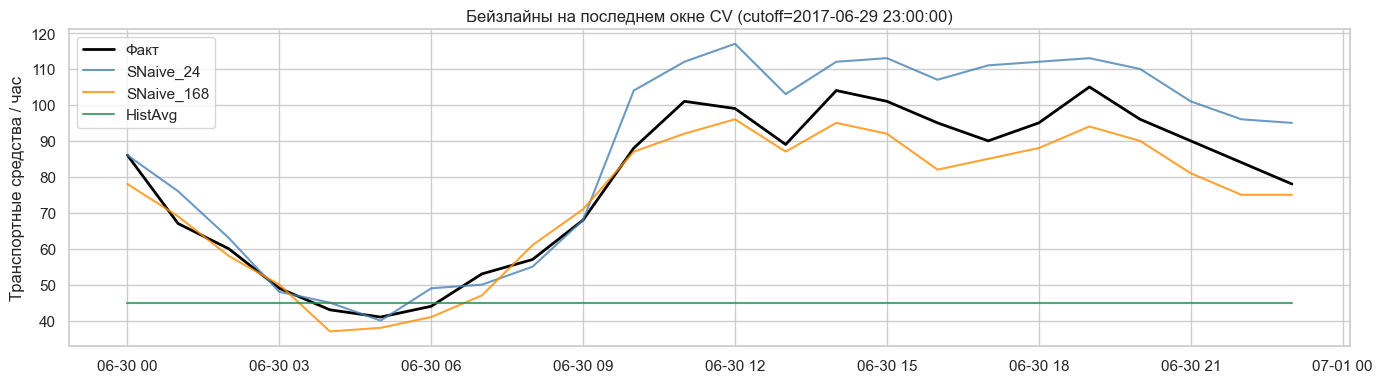

In [25]:
# Визуализация прогнозов на последнем окне CV
last_cutoff = cv_base['cutoff'].max()
last_window = cv_base[cv_base['cutoff'] == last_cutoff].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(last_window['ds'], last_window['y'], label='Факт', color='black', linewidth=2)
for m, color in zip(baseline_cols, ['steelblue', 'darkorange', 'seagreen']):
    ax.plot(last_window['ds'], last_window[m], label=m, color=color, alpha=0.8)
ax.set_title(f'Бейзлайны на последнем окне CV (cutoff={last_cutoff})')
ax.set_ylabel('Транспортные средства / час')
ax.legend()
plt.tight_layout()
plt.show()

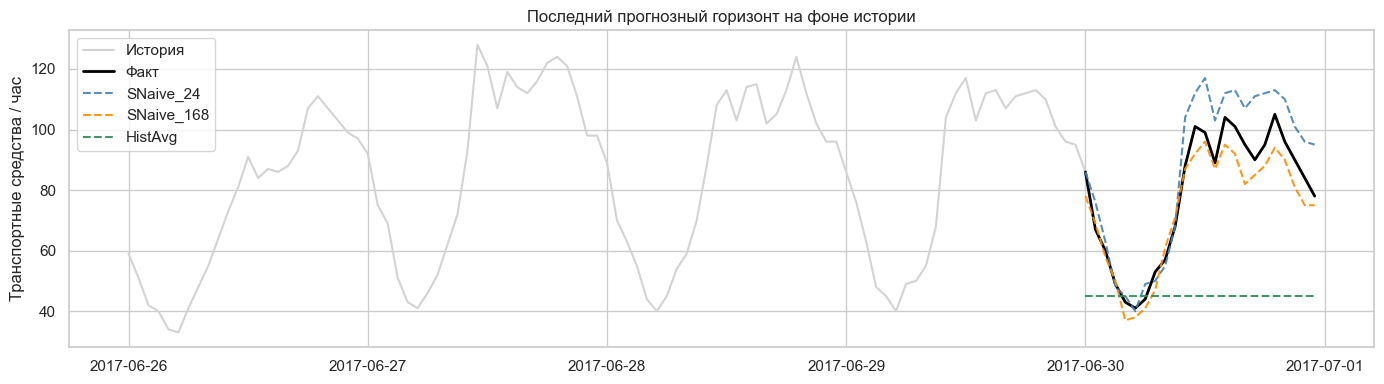

In [26]:
# История + прогноз: удобно видеть, откуда модель стартует
history_tail = sf_df.tail(24 * 5).copy()  # последние 5 суток истории
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(history_tail['ds'], history_tail['y'], color='lightgray', label='История')
ax.plot(last_window['ds'], last_window['y'], color='black', linewidth=2, label='Факт')
for m, color in zip(baseline_cols, ['steelblue', 'darkorange', 'seagreen']):
    ax.plot(last_window['ds'], last_window[m], '--', color=color, label=m, alpha=0.9)
ax.set_title('Последний прогнозный горизонт на фоне истории')
ax.set_ylabel('Транспортные средства / час')
ax.legend()
plt.tight_layout()
plt.show()